# A bending yardstick: two decades of a wild sea-urchin sentinel

**Off Livorno, North Tyrrhenian Sea — ISPRA reference-toxicant time series, 2003–2026.**

The copper EC50 of the *Paracentrotus lividus* embryo test is a **positive control** — a
reference-toxicant yardstick run to validate the assay for regulatory biomonitoring. Over
20 years it fell ~41%. Sartori, Scatena, Vrinceanu & Gaion (2023, *Mar. Pollut. Bull.* 194A)
already reported this decline and its correlation with ocean acidification. This notebook goes
one step further and asks **what kind of change it is**, by *excluding alternatives* rather than
asserting a cause:

1. Is the decline **chemistry** (copper became more bioavailable) or **biology** (the larvae changed)?
2. Is it **temperature** alone?
3. What actually changed, and **when** — a multifactorial regime shift on a wild population.

The urchins are **wild-collected**, so their gametes carry the imprint of the sea their parents
lived in. Copper is only the *revealer* of the population's condition, dosed identically (certified
ICP standards) throughout — so a change in EC50 is a change in the animals, not in the reagent.


In [1]:
import json, subprocess, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from climate_change_on_sea_urchins import load_data
from climate_change_on_sea_urchins import cu_speciation, thermal_legacy, regime_shift, mhw_lag_annual

RESULTS, FIGS = Path("results"), Path("figures")
def run_fig(script):  # regenerate a figure reproducibly
    subprocess.run([sys.executable, f"scripts/{script}"], check=True)

df_full, df_real, events, monthly = load_data()
real = df_real.dropna(subset=["EC50"])
print(f"{len(real)} real EC50 measurements, "
      f"{df_full.Datetime.min().date()} – {df_full.Datetime.max().date()}")
print(f"pre-2016 mean EC50 = {real[real.Datetime.dt.year<2016].EC50.mean():.1f} µg/L | "
      f"post = {real[real.Datetime.dt.year>=2016].EC50.mean():.1f} µg/L")

161 real EC50 measurements, 2003-01-01 – 2026-05-01
pre-2016 mean EC50 = 47.0 µg/L | post = 27.8 µg/L


## The robust fact: the yardstick bent

A monotonic ~41% decline. This is not in question — it is the starting point, not the finding.


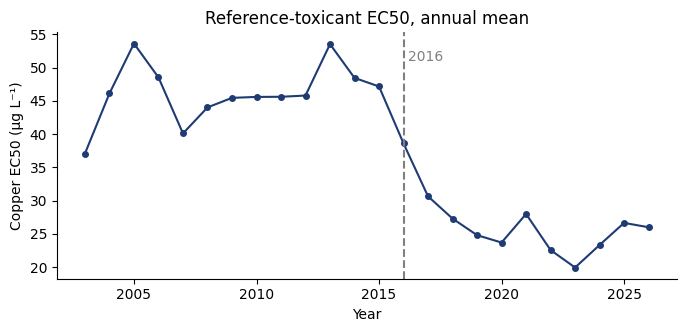

In [2]:
ann = real.assign(y=real.Datetime.dt.year).groupby("y")["EC50"].mean()
fig, ax = plt.subplots(figsize=(8,3.2))
ax.plot(ann.index, ann.values, "-o", ms=4, color="#1f3b73")
ax.axvline(2016, ls="--", color="grey"); ax.text(2016.2, ann.max()*0.95, "2016", color="grey")
ax.set_ylabel("Copper EC50 (µg L⁻¹)"); ax.set_xlabel("Year")
ax.set_title("Reference-toxicant EC50, annual mean"); ax.spines[["top","right"]].set_visible(False)
plt.show()

## Question 1 — chemistry or biology?

The toxic form of copper is the free ion Cu²⁺; ocean acidification frees more of it from carbonate
complexes, so *some* of the decline could be pure water chemistry. We compute the free-Cu²⁺ fraction
from the carbonate system at each assay's measured pH/T/S and correct the EC50 for it.


✓ cu_speciation: nominal EC50 decline 40.8% | geochemical share 3% (lit) / 1% (carbonate); residual biological decline 39.6% (p=2.6e-22)


✓ wrote figures/fig_cu_speciation_decomposition.png
✓ wrote drafts/nuova pubblicazione/fig_cu_speciation_decomposition.png


Realized pH change pre→post: -0.011 units
Nominal EC50 decline:            40.8%
Explained by OA chemistry:       ~3%
Residual (biological) decline:   39.6%  (Mann-Whitney p=3e-22)


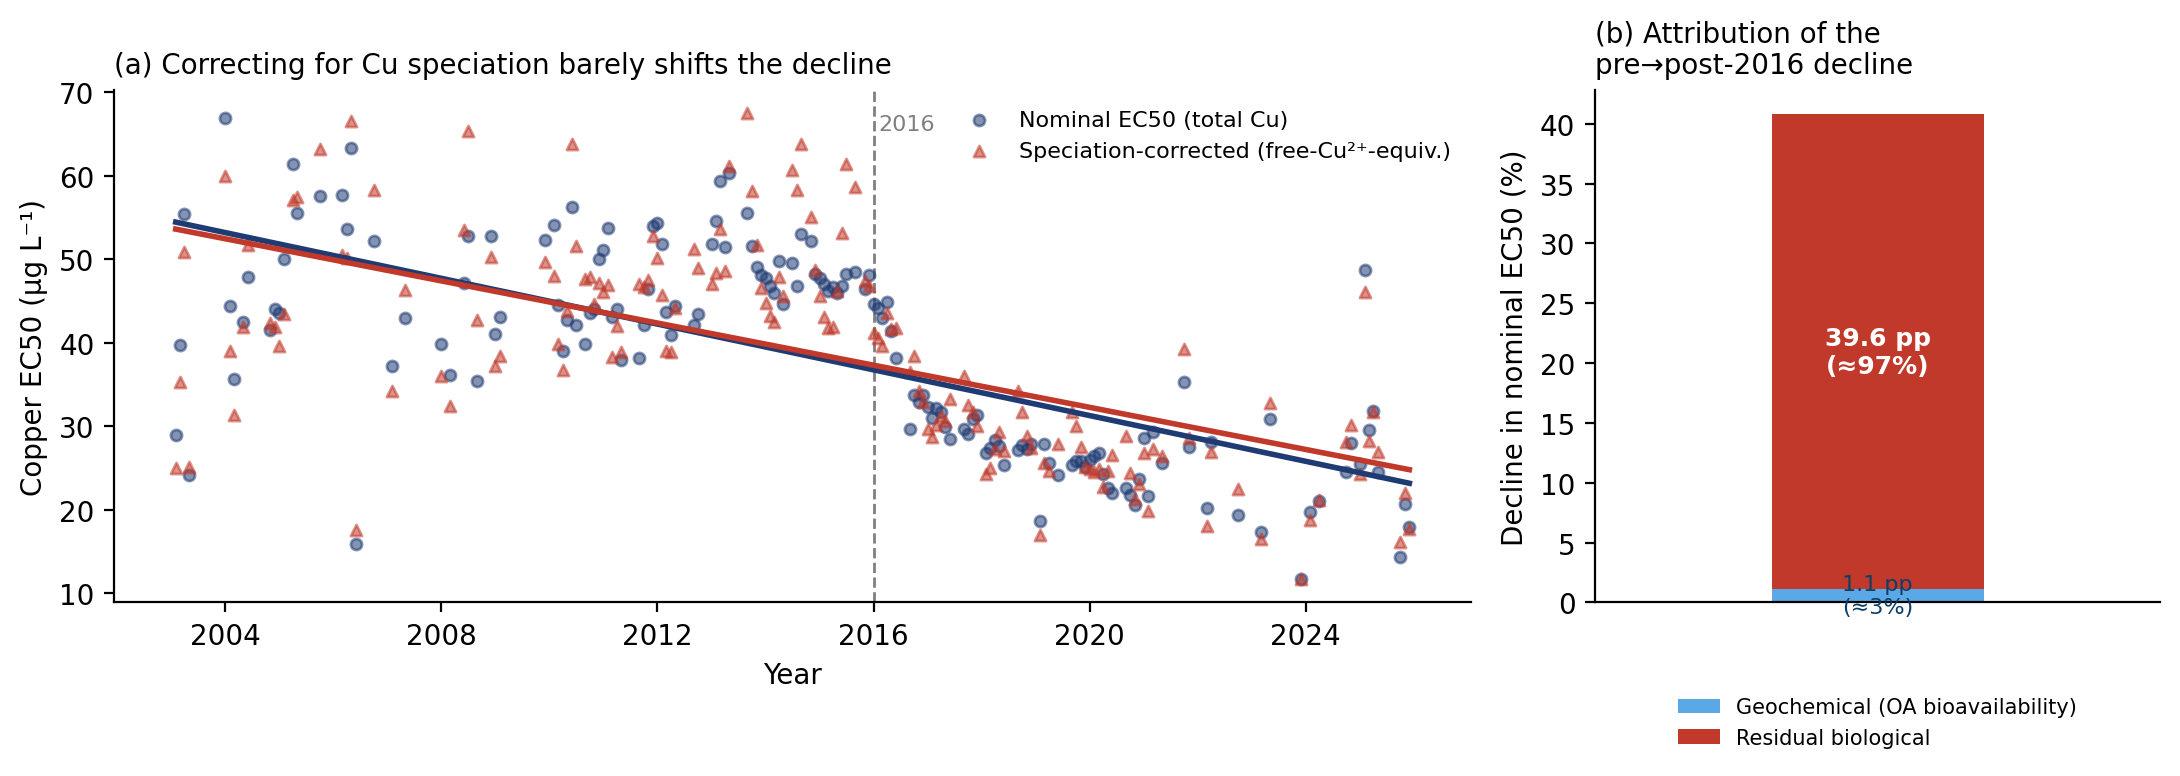

In [3]:
cu_speciation.run(); run_fig("make_speciation_figure.py")
s = json.load(open(RESULTS/"cu_speciation_summary.json"))
print(f"Realized pH change pre→post: {s['delta_pH']:+.3f} units")
print(f"Nominal EC50 decline:            {s['ec50_decline_nominal_pct']:.1f}%")
print(f"Explained by OA chemistry:       ~{s['geochemical_share_literature_pct']:.0f}%")
print(f"Residual (biological) decline:   {s['ec50_decline_corrected_literature_pct']:.1f}%  "
      f"(Mann-Whitney p={s['biological_residual_mannwhitney_p']:.0e})")
display(Image(str(FIGS/"fig_cu_speciation_decomposition.png")))

**Verdict:** the site pH moved only ~0.01 units, so copper bioavailability accounts for at most a
few percent. The speciation-corrected EC50 still falls ~40%. **The sensitization is genuinely
biological — not a water-chemistry artifact.** (Chemistry excluded.)


## Question 2 — is it temperature alone?

If chronic heat stress on the wild adults drives it, cumulative thermal dose (degree-days above the
reproductive threshold) should predict EC50 *better than the mere passage of time*. That is the
decisive control, because both trend.


✓ thermal_legacy: raw -0.67 (p=1.4e-22) but detrended p=0.00, ΔR² over time 4.7% → consistent_but_not_separable_from_trend


✓ wrote figures/fig_thermal_legacy.png
✓ wrote drafts/nuova pubblicazione/fig_thermal_legacy.png


Raw correlation (18C/36m):     rho=-0.67 (p=1e-22)
After removing the time trend:      p=0.00
Extra R² over a plain time trend:   4.7%
Verdict: consistent_but_not_separable_from_trend


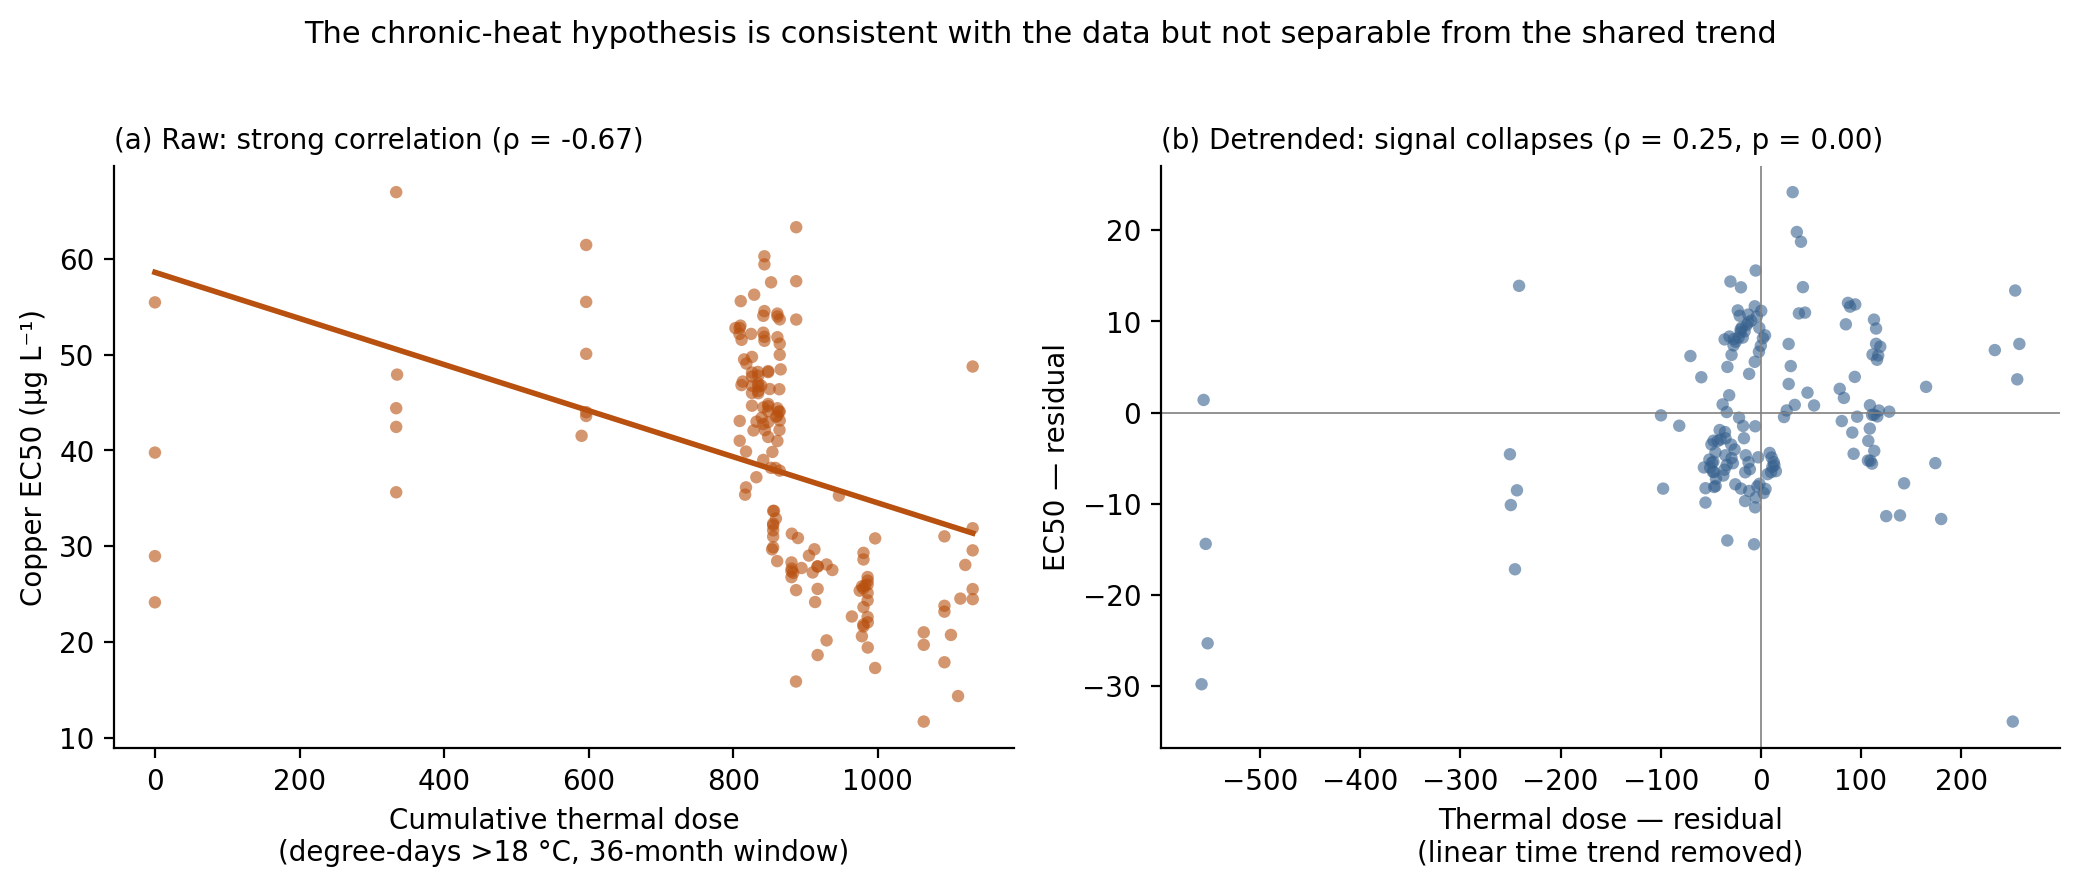

In [4]:
thermal_legacy.run(); run_fig("make_thermal_legacy_figure.py")
t = json.load(open(RESULTS/"thermal_legacy_summary.json"))
sr = t["strongest_raw"]
print(f"Raw correlation ({sr['window']}):     rho={sr['raw_spearman_r']:+.2f} (p={sr['raw_p']:.0e})")
print(f"After removing the time trend:      p={t['same_window_detrended_p']:.2f}")
print(f"Extra R² over a plain time trend:   {t['same_window_delta_r2_over_time']*100:.1f}%")
print(f"Verdict: {t['verdict']}")
display(Image(str(FIGS/"fig_thermal_legacy.png")))

**Verdict:** an impressive raw correlation that collapses once the shared trend is removed —
thermal dose is ~0.7 collinear with time and adds almost nothing. **Temperature as a single linear
driver is not enough.** (Temperature-alone excluded → the stress must be multifactorial.)


## Question 3 — a multifactorial regime shift

Pettitt changepoints, a PCA stress index over the five climate-change-sensitive variables, and
early-warning-signal diagnostics — reported honestly.


✓ regime_shift: EC50 break 2016-05-01 (p=2.2e-22); MHW exposure break 2013 (~3 yr earlier); stress PC1=71%; critical slowing down: NOT detected


✓ wrote figures/fig_regime_shift.png
✓ wrote drafts/nuova pubblicazione/fig_regime_shift.png


EC50 regime shift:        2016-05-01 (p=2e-22)
Environment shifts:       ~2013 (MHW days, T, CO2, pH together)
Accumulation lag:         ~3 years (exposure → response)
Stress axis PC1 variance: 71%
Critical slowing down:    NOT detected


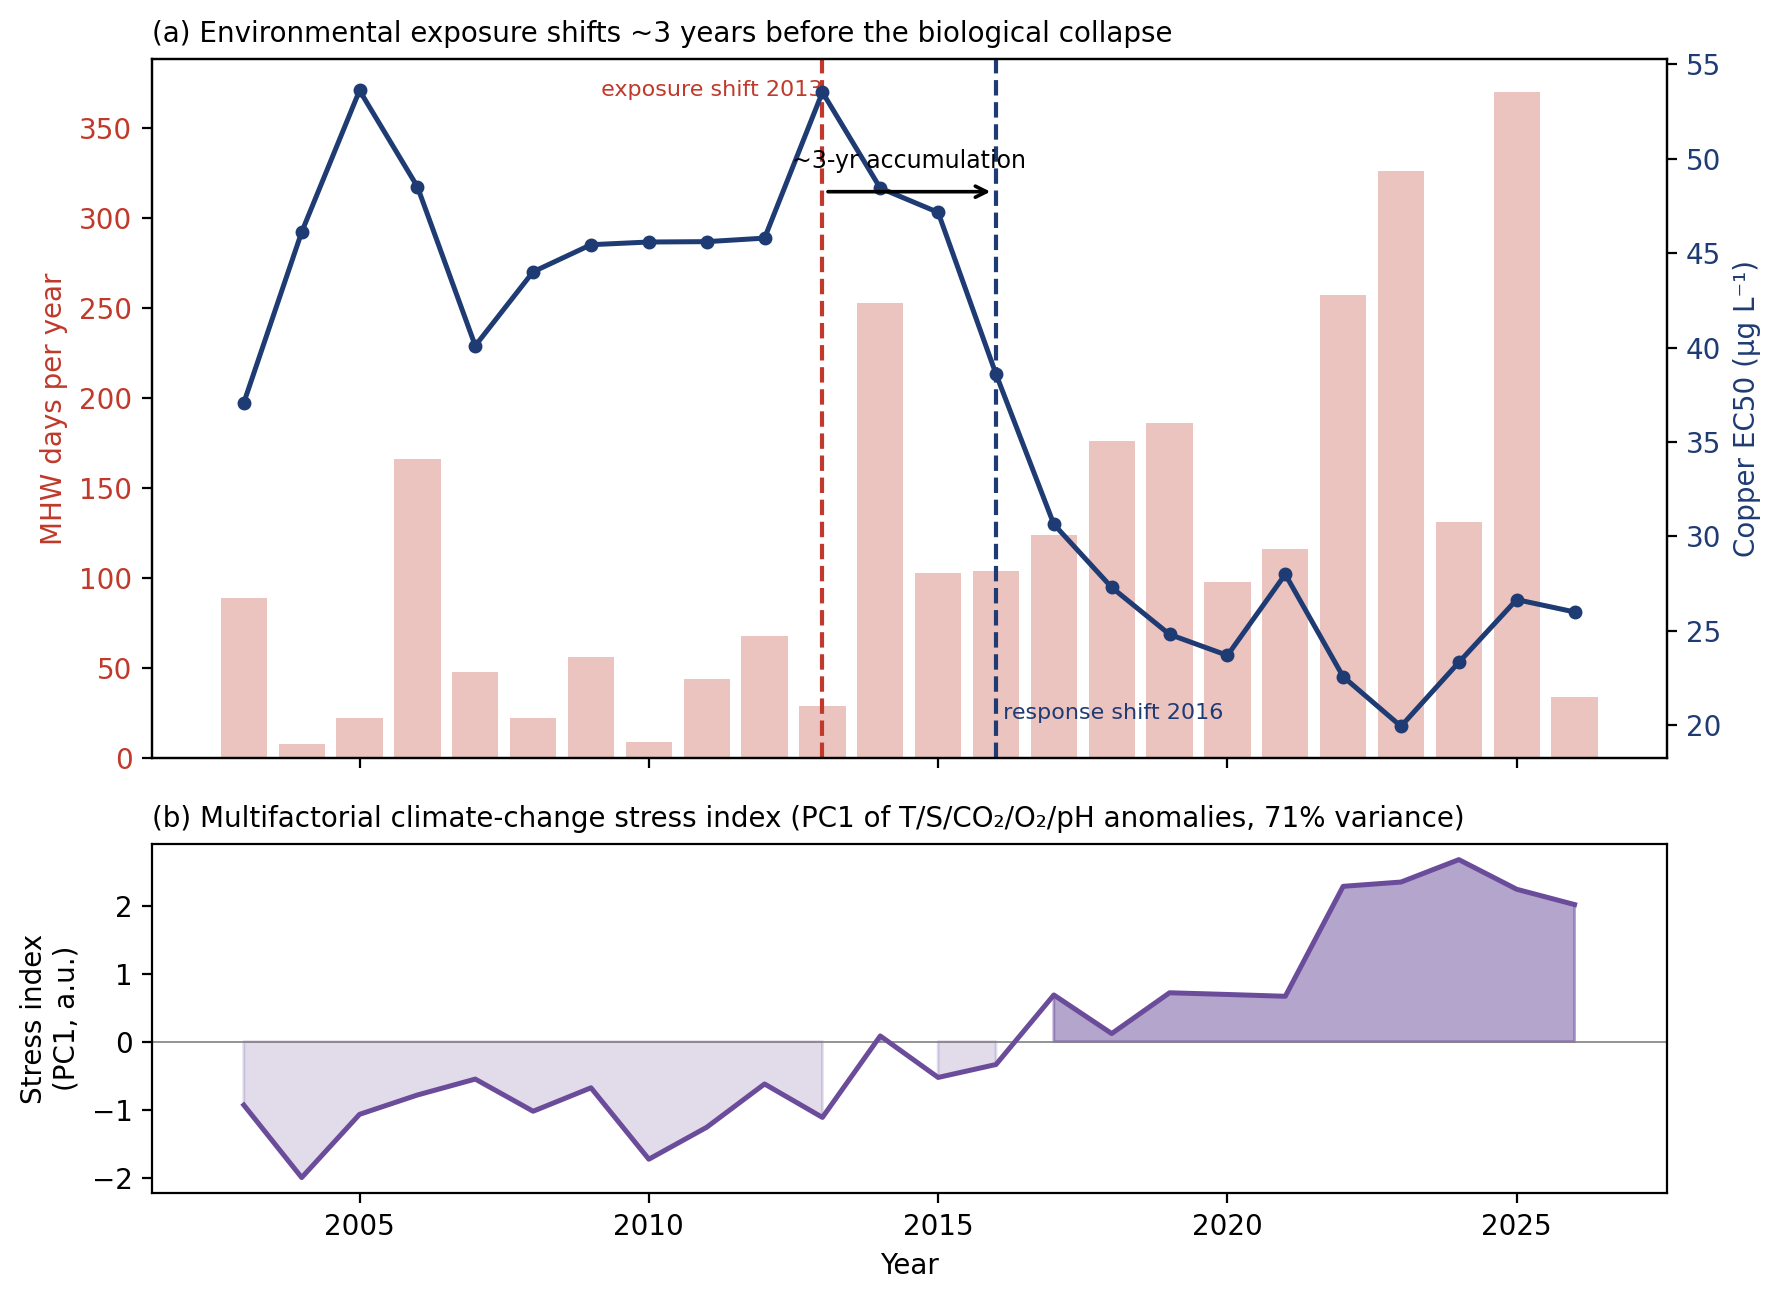

In [5]:
regime_shift.run(); run_fig("make_regime_shift_figure.py")
r = json.load(open(RESULTS/"regime_shift_summary.json"))
print(f"EC50 regime shift:        {r['ec50_regime_shift']['break']} (p={r['ec50_regime_shift']['p']:.0e})")
print(f"Environment shifts:       ~{r['mhw_exposure_break_year']} (MHW days, T, CO2, pH together)")
print(f"Accumulation lag:         ~{r['exposure_precedes_response_years']} years (exposure → response)")
print(f"Stress axis PC1 variance: {r['multifactorial_stress_index']['pc1_variance_explained']*100:.0f}%")
print(f"Critical slowing down:    {'detected' if r['critical_slowing_down_detected'] else 'NOT detected'}")
display(Image(str(FIGS/"fig_regime_shift.png")))

**Verdict:** the population's copper tolerance changes state ~2016, about **three years after**
the whole environmental complex (marine-heatwave exposure, temperature, CO₂, pH) shifts ~2013 —
consistent with multi-year accumulation on long-lived wild adults. One coordinated
warming+acidification+deoxygenation axis carries most of the environmental variance.

**Honest boundary:** this is a documented **regime shift**, *not* a demonstrated **tipping point**.
The canonical critical-slowing-down early-warning signals (rising variance and autocorrelation) are
**absent**, so we do not claim a dynamical critical transition.


## Question 4 — is there *any* MHW signal left after the trend? (exploratory)

Everything so far is co-trended. But one fragment survives. Does the **duration** of heatwave
exposure predict EC50 *beyond* the shared trend, at some lag? We scan predictor × lag on annual data,
detrend both series, and stress-test the survivor (jackknife, Pearson, FDR, direction).


✓ mhw_lag_annual: best = total_mhw_days lag 1yr (detrended rho=-0.48, p=0.023, FDR=0.37); jackknife 95% <0.05; Pearson p=0.20 → exploratory_suggestive


✓ wrote figures/fig_mhw_lag_annual.png
✓ wrote drafts/nuova pubblicazione/fig_mhw_lag_annual.png


Best predictor:   total_mhw_days at lag 1 yr (exposure DURATION)
Detrended:        rho=-0.48, p=0.023
Event COUNT lag1: p=0.31  (number of events → nothing)
Jackknife <0.05:  95% of leave-one-year-out refits
Pearson:          r=-0.29, p=0.20  (rank-driven, not linear)
Reverse (EC50→MHW): rho=+0.17, p=0.44
Survives FDR:     no (p_FDR=0.37)
Verdict:          exploratory_suggestive


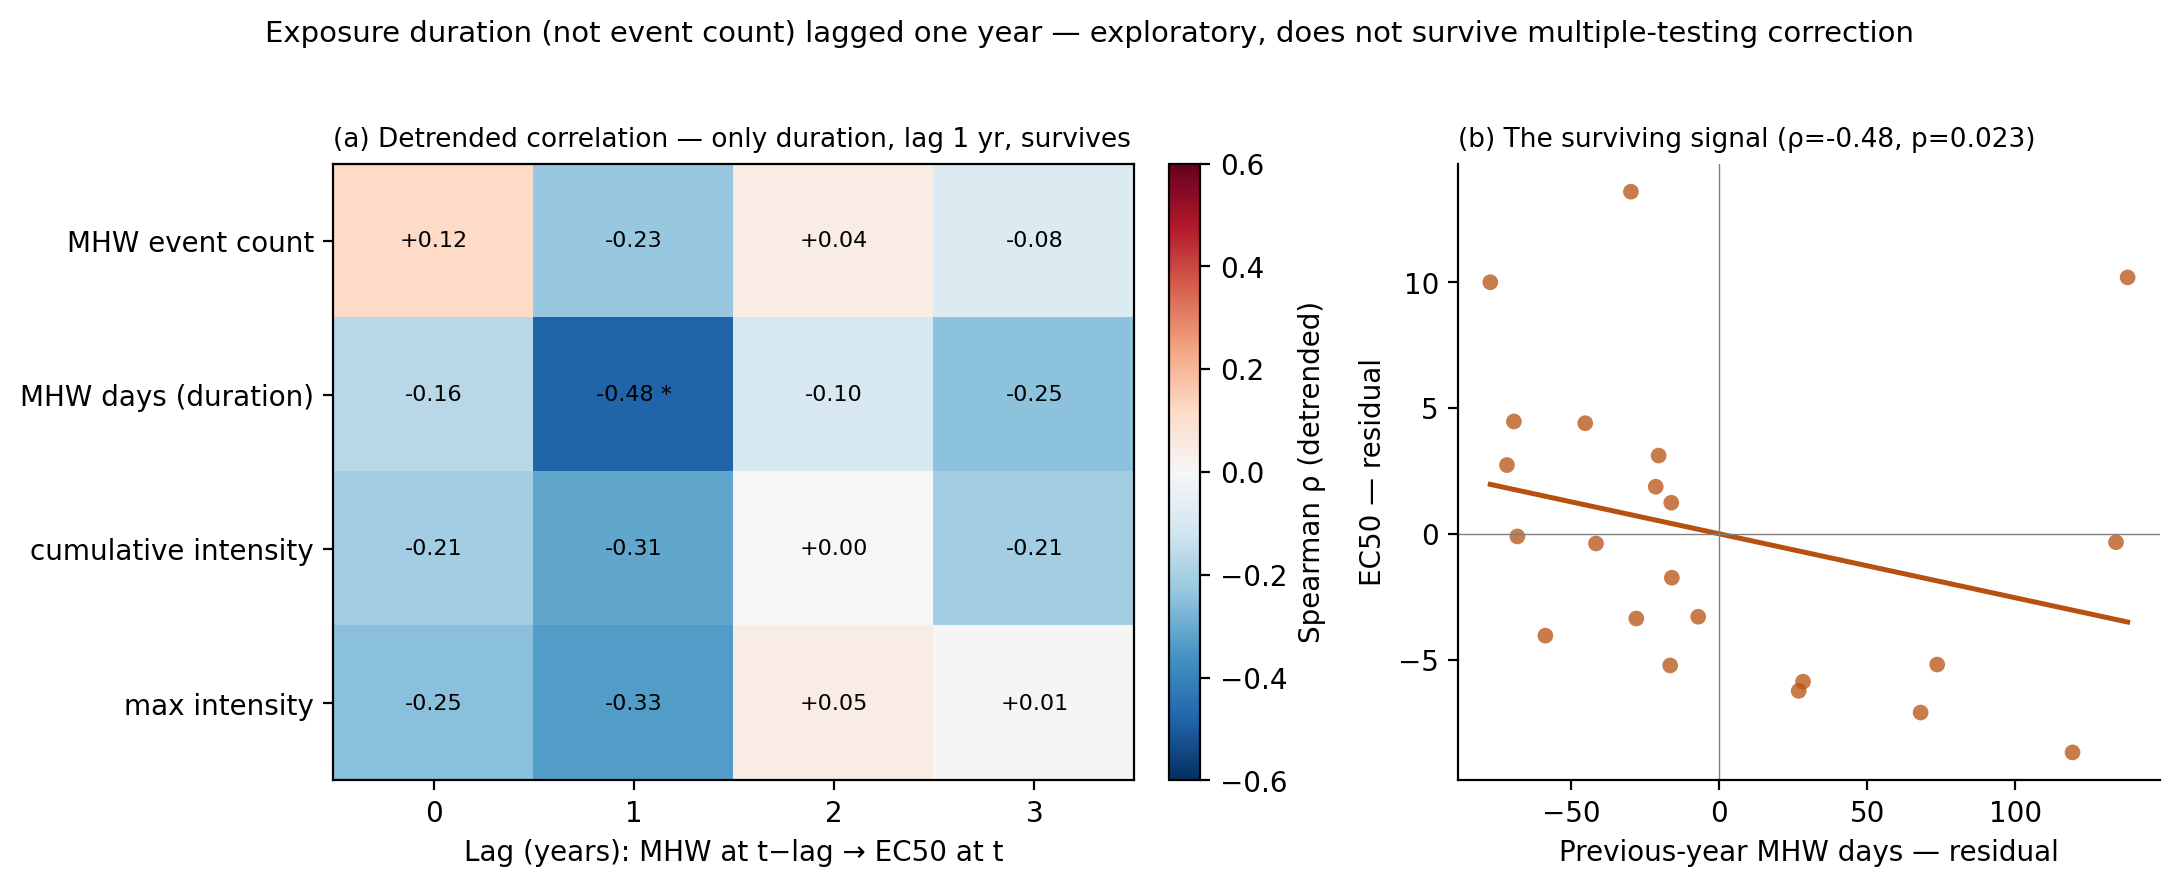

In [6]:
mhw_lag_annual.run(); run_fig("make_mhw_lag_annual_figure.py")
m = json.load(open(RESULTS/"mhw_lag_annual_summary.json"))
bs, rb = m["best_signal"], m["robustness"]
print(f"Best predictor:   {bs['predictor']} at lag {bs['lag_years']} yr (exposure DURATION)")
print(f"Detrended:        rho={bs['rho_detrended_spearman']:+.2f}, p={bs['p_detrended_spearman']:.3f}")
print(f"Event COUNT lag1: p={m['event_count_lag1_detrended_p']:.2f}  (number of events → nothing)")
print(f"Jackknife <0.05:  {rb['jackknife_frac_below_0p05']*100:.0f}% of leave-one-year-out refits")
print(f"Pearson:          r={rb['pearson_r']:+.2f}, p={rb['pearson_p']:.2f}  (rank-driven, not linear)")
print(f"Reverse (EC50→MHW): rho={rb['reverse_direction_rho']:+.2f}, p={rb['reverse_direction_p']:.2f}")
print(f"Survives FDR:     {'yes' if bs['p_detrended_fdr_bh']<0.05 else 'no'} (p_FDR={bs['p_detrended_fdr_bh']:.2f})")
print(f"Verdict:          {m['verdict']}")
display(Image(str(FIGS/"fig_mhw_lag_annual.png")))

**Verdict:** the *duration* of the previous year's heatwaves — not the *number* of events —
predicts EC50 after detrending (ρ=−0.48, p=0.023), the only MHW signal that survives. It is robust to
jackknife (95% of leave-one-year-out refits stay significant) and direction-asymmetric (MHW→EC50, not
the reverse), but Pearson-weak and it does **not** survive multiple-testing correction. This is a
**delayed ~1-year carry-over** hypothesis — heat stress on one season's gametes surfacing the next —
distinct from the acute effect the 2025 experiment correctly found absent. **Exploratory: worth
pre-registering, not a demonstrated effect.**


## Synthesis — inference by exclusion

| Candidate explanation | Test | Outcome |
|---|---|---|
| Copper bioavailability (ocean acidification) | speciation decomposition | ~3% — **excluded** |
| Assay imprecision / method drift | CI width, replicates, ICP-dosed reference | ~constant — **excluded** |
| Food / productivity | Chl, phyto, nutrients vs EC50 | null — **excluded** |
| Temperature alone | cumulative thermal dose vs time | insufficient — **excluded** |
| **Multifactorial cumulative climate stress** | regime shift + timing + PC1 | **only survivor** |
| Delayed MHW *duration* carry-over (t−1) | annual lagged, detrended + jackknife | **suggestive** — survives detrending, *not* FDR (exploratory) |

**What we can say:** a wild sentinel population underwent a ~2016 regime shift in contaminant
tolerance, ~3 years after a coordinated multifactorial change in its environment; every simpler
explanation is excluded. **What we cannot say:** direct causation — a single observational,
co-trending time series cannot prove it. The contribution is the *eliminative inference* plus the
*reproducible open-science pipeline* that produced every number above, not a new correlation.

**Regulatory implication (ISPRA):** the reference-toxicant baseline that biomonitoring assumes is
stationary is not — with consequences for QA/QC and for copper environmental-quality thresholds set
on total dissolved copper.
